# The fast path: one compiled graph from photometry to posteriors

Every `fit_*` call so far pays Python-loop and retrace overhead per star.
`make_hmc_pipeline` removes all of it: window adaptation, kernel, and the
sampling scan trace into **one XLA program** with the observed magnitudes as a
traced argument —

```
pipeline(key, mags) -> ({teff, logg, feh, mu} posterior samples, diagnostics)
```

The compile is paid once; each additional star is pure device execution. And
because the pipeline is a pure JAX function, `jax.vmap` turns it into a
**catalog engine**: every star sampled in a single XLA call.

Grid: the real TSLTE table (notebook 03). Sampler: HMC with fixed
integration length — cheaper per step than NUTS (no tree doubling), and the
mass-matrix adaptation handles the parameter scales.

In [1]:
import time
from pathlib import Path

import corner
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from tengri import Uniform

from tengri_stars import StarModel, fit_nss, load_photometry_grid, make_hmc_pipeline

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(23)

DATA = (
    Path("data") if (Path("data") / "TSLTE_combined_photometry.fits").exists() else Path("../data")
)

W0710 00:22:32.766573   73075 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


## 1. Model, priors, and the two-argument likelihood

The likelihood takes the data as an argument — that is what lets one compiled
program serve every star.

In [2]:
grid = load_photometry_grid(DATA / "TSLTE_combined_photometry.fits", fill="nearest")
model = StarModel(grid=grid, interp_method="pchip")
SIG_MAG = 0.02

priors = {
    "teff": Uniform(float(grid.axes[0][0]), float(grid.axes[0][-1])),
    "logg": Uniform(float(grid.axes[1][0]), float(grid.axes[1][-1])),
    "feh": Uniform(float(grid.axes[2][0]), float(grid.axes[2][-1])),
    "mu": Uniform(-28.0, -8.0),
}


def loglikelihood(p, mags):
    pred = model.predict_mags(teff=p["teff"], logg=p["logg"], feh=p["feh"], mu=p["mu"])
    return -0.5 * jnp.sum(((pred - mags) / SIG_MAG) ** 2)


pipeline = make_hmc_pipeline(
    loglikelihood, priors, num_warmup=500, num_samples=1000, num_integration_steps=32
)

W0710 00:22:34.303476   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:22:34.306847   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:22:34.310624   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:22:34.361336   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:22:34.438764   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:22:34.442294   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:22:34.445227   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## 2. Single star: compile once, then pure device execution

In [3]:
truth = {"teff": 4600.0, "logg": 2.0, "feh": -1.5, "mu": -18.0}
mags_obs = jnp.asarray(
    np.asarray(model.predict_mags(**truth)) + rng.normal(0.0, SIG_MAG, len(grid.filter_names))
)

t0 = time.time()
samples, info = jax.block_until_ready(pipeline(jax.random.PRNGKey(0), mags_obs))
t_cold = time.time() - t0

t0 = time.time()
samples, info = jax.block_until_ready(pipeline(jax.random.PRNGKey(1), mags_obs))
t_warm = time.time() - t0

print(f"cold (with XLA compile): {t_cold:5.1f} s")
print(f"warm (pure execution):   {t_warm:5.2f} s/star")
print(f"acceptance {float(info['acceptance_rate']):.2f}, {int(info['num_divergent'])} divergences")
for n in priors:
    q = np.percentile(np.asarray(samples[n]), [16, 50, 84])
    print(f"  {n:5s} truth {truth[n]:9.2f}:  {q[1]:9.2f}  68% [{q[0]:9.2f}, {q[2]:9.2f}]")

W0710 00:22:35.602884   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:22:35.606014   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0710 00:22:35.868881   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:22:35.909264   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:22:35.912288   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:22:35.927483   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:22:35.930580   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:22:35.945492   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:22:35.960342   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:22:35.963613   72921 pjrt_executable.cc:638] Assume v

W0710 00:22:36.253248   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0710 00:22:37.066760   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:22:37.083907   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:22:37.100179   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:22:37.103969   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0710 00:22:37.575184   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


cold (with XLA compile):   3.6 s
warm (pure execution):    3.00 s/star
acceptance 0.95, 0 divergences
  teff  truth   4600.00:    4633.38  68% [  4601.69,   4671.05]
  logg  truth      2.00:       1.79  68% [     1.50,      2.08]
  feh   truth     -1.50:      -1.48  68% [    -1.59,     -1.37]
  mu    truth    -18.00:     -17.96  68% [   -18.00,    -17.91]


## 3. Catalog mode: vmap over 100 stars, one XLA call

In [4]:
N_STARS = 100
truths = {
    "teff": rng.uniform(4000.0, 6500.0, N_STARS),
    "logg": rng.uniform(1.0, 4.5, N_STARS),
    "feh": rng.uniform(-3.5, -0.5, N_STARS),
    "mu": np.full(N_STARS, -18.0),
}
clean = np.stack(
    [
        np.asarray(
            model.predict_mags(
                teff=truths["teff"][i],
                logg=truths["logg"][i],
                feh=truths["feh"][i],
                mu=truths["mu"][i],
            )
        )
        for i in range(N_STARS)
    ]
)
mags_batch = jnp.asarray(clean + rng.normal(0.0, SIG_MAG, clean.shape))
keys = jax.random.split(jax.random.PRNGKey(3), N_STARS)

catalog_pipeline = jax.jit(jax.vmap(pipeline))

t0 = time.time()
cat_samples, cat_info = jax.block_until_ready(catalog_pipeline(keys, mags_batch))
t_cat_cold = time.time() - t0
t0 = time.time()
cat_samples, cat_info = jax.block_until_ready(catalog_pipeline(keys, mags_batch))
t_cat_warm = time.time() - t0

print(f"catalog of {N_STARS} stars, full HMC posteriors each:")
print(f"  cold (compile): {t_cat_cold:6.1f} s")
print(f"  warm:           {t_cat_warm:6.1f} s  →  {t_cat_warm / N_STARS * 1000:.0f} ms/star")
print(f"  median acceptance: {float(jnp.median(cat_info['acceptance_rate'])):.2f}")

W0710 00:22:43.718022   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0710 00:22:44.411594   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0710 00:22:45.041768   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


catalog of 100 stars, full HMC posteriors each:
  cold (compile):   83.7 s
  warm:             83.6 s  →  836 ms/star
  median acceptance: 0.95


W0710 00:25:31.711619   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## 4. Catalog recovery — the MAGIC-style validation plot

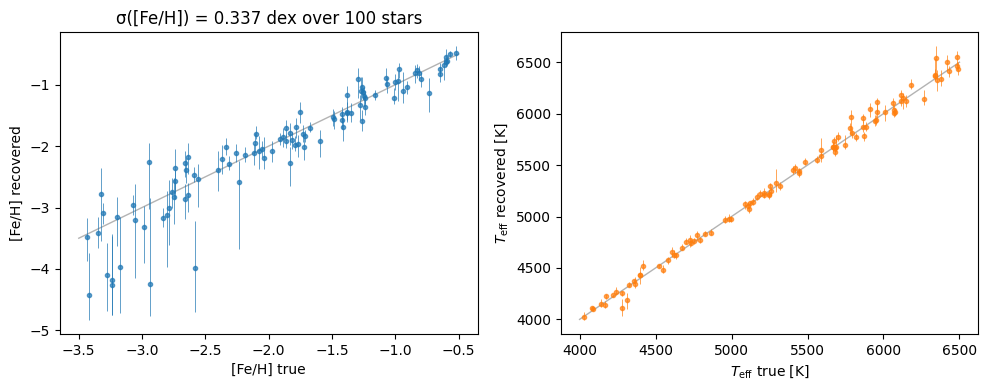

In [5]:
feh_med = np.median(np.asarray(cat_samples["feh"]), axis=1)
feh_lo, feh_hi = np.percentile(np.asarray(cat_samples["feh"]), [16, 84], axis=1)
teff_med = np.median(np.asarray(cat_samples["teff"]), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].errorbar(
    truths["feh"],
    feh_med,
    yerr=[feh_med - feh_lo, feh_hi - feh_med],
    fmt="o",
    ms=3,
    lw=0.7,
    alpha=0.7,
)
axes[0].plot([-3.5, -0.5], [-3.5, -0.5], color="0.7", lw=1, zorder=0)
scatter = np.std(feh_med - truths["feh"])
axes[0].set(
    xlabel="[Fe/H] true",
    ylabel="[Fe/H] recovered",
    title=f"σ([Fe/H]) = {scatter:.3f} dex over {N_STARS} stars",
)
axes[1].errorbar(
    truths["teff"],
    teff_med,
    yerr=np.abs(np.percentile(np.asarray(cat_samples["teff"]), [16, 84], axis=1) - teff_med),
    fmt="o",
    ms=3,
    lw=0.7,
    alpha=0.7,
    color="C1",
)
axes[1].plot([4000, 6500], [4000, 6500], color="0.7", lw=1, zorder=0)
axes[1].set(xlabel=r"$T_{\rm eff}$ true [K]", ylabel=r"$T_{\rm eff}$ recovered [K]")
plt.tight_layout()
plt.show()

## 5. Cross-check against NSS on one star

W0710 00:25:31.865058   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:25:31.869762   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:25:31.872413   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:25:31.882385   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0710 00:25:32.079280   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0710 00:25:32.613965   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0710 00:25:34.910985   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:25:34.956942   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:25:34.962093   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0710 00:25:35.125934   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0710 00:25:35.532897   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:25:35.586481   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0710 00:25:35.971726   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:25:36.019397   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:25:36.095795   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:25:36.098816   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:25:36.102323   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0710 00:25:36.183346   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:25:36.198197   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:25:36.261960   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:25:36.264901   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:25:36.267774   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0710 00:25:36.295499   72921 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


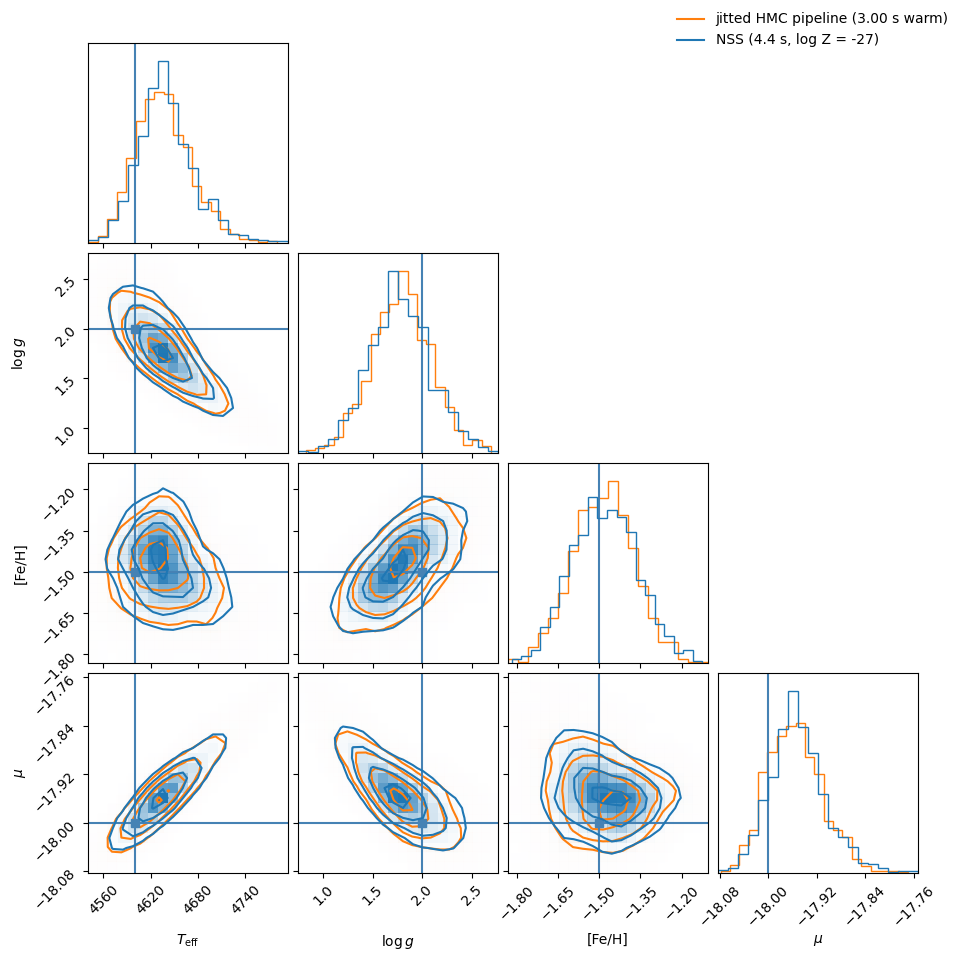

In [6]:
t0 = time.time()
nss = fit_nss(
    loglikelihood, priors, key=jax.random.PRNGKey(4), data=mags_obs, n_live=400, num_delete=40
)
t_nss = time.time() - t0

names = list(priors)
stack_hmc = np.column_stack([np.asarray(samples[n]) for n in names])
stack_nss = np.column_stack([np.asarray(nss.samples[n]) for n in names])
fig = corner.corner(
    stack_hmc,
    labels=[r"$T_{\rm eff}$", r"$\log g$", "[Fe/H]", r"$\mu$"],
    truths=[truth[n] for n in names],
    color="C1",
    hist_kwargs={"density": True},
    plot_datapoints=False,
    smooth=1.0,
)
corner.corner(
    stack_nss,
    fig=fig,
    color="C0",
    hist_kwargs={"density": True},
    plot_datapoints=False,
    smooth=1.0,
)
fig.legend(
    handles=[
        plt.Line2D([], [], color="C1", label=f"jitted HMC pipeline ({t_warm:.2f} s warm)"),
        plt.Line2D([], [], color="C0", label=f"NSS ({t_nss:.1f} s, log Z = {nss.logz:.0f})"),
    ],
    loc="upper right",
    frameon=False,
)
plt.show()

## When to use which

- **Jitted HMC pipeline**: the throughput path — catalogs, well-constrained
  stars (many bands / CaHK / joint spectra), unimodal posteriors. Milliseconds
  per star once compiled.
- **NSS**: the robustness path — dwarf/giant bimodality (notebook 04),
  evidence for model comparison, no gradients needed. Seconds per star.
- A production MAGIC-scale strategy: jitted pipeline for everything, NSS
  re-runs for stars flagged multimodal (low acceptance, suspicious χ²,
  parallax–photometry tension).